# Challenge — Red neuronal con Keras 3
### Universidad EAFIT | SI3003 — Introducción a la Inteligencia Artificial

---

## Objetivo

En clase construimos una red neuronal para clasificación de imágenes usando **Keras 3**.

En este ejercicio aplicarás **la misma receta** sobre un dataset diferente: **CIFAR-10 convertido a escala de grises**.

No necesitas diseñar un pipeline nuevo. La descarga, conversión a escala de grises y visualización están resueltas. Tu trabajo es completar únicamente las etapas de Keras que vimos en clase:

```text
Datos → Normalización → Modelo → Loss + Optimizer → fit() → evaluate() → Predicción
```

Las celdas marcadas con `# TODO` son las que debes completar.


---
## 0. Librerías


In [1]:
import keras
from keras import layers
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
keras.utils.set_random_seed(SEED)

print(f"Keras version : {keras.__version__}")
print(f"Backend       : {keras.backend.backend()}")


Keras version : 3.15.1
Backend       : torch


---
# 1. Dataset: CIFAR-10

CIFAR-10 contiene 50,000 imágenes de entrenamiento y 10,000 de prueba. Las imágenes originales son de **32×32×3** y pertenecen a 10 categorías:

`airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck`.


In [2]:
# Esta parte está resuelta.
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

y_train = y_train.squeeze()
y_test = y_test.squeeze()

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print("X_train original:", X_train.shape)
print("X_test original :", X_test.shape)
print("y_train         :", y_train.shape)


        0/170498071 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

     8192/170498071 ━━━━━━━━━━━━━━━━━━━━ 35:13 12us/step

    16384/170498071 ━━━━━━━━━━━━━━━━━━━━ 35:03 12us/step

    32768/170498071 ━━━━━━━━━━━━━━━━━━━━ 26:16 9us/step 

    49152/170498071 ━━━━━━━━━━━━━━━━━━━━ 23:30 8us/step

...

170459136/170498071 ━━━━━━━━━━━━━━━━━━━━ 0s 6us/step

170475520/170498071 ━━━━━━━━━━━━━━━━━━━━ 0s 6us/step

170491904/170498071 ━━━━━━━━━━━━━━━━━━━━ 0s 6us/step

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1086s 6us/step


X_train original: (50000, 32, 32, 3)
X_test original : (10000, 32, 32, 3)
y_train         : (50000,)


## 1.1 RGB → escala de grises

Usaremos la transformación:

$$Gray = 0.299R + 0.587G + 0.114B$$

Esta parte está resuelta porque el objetivo del ejercicio es practicar Keras.


In [3]:
X_train = (
    0.299 * X_train[..., 0] +
    0.587 * X_train[..., 1] +
    0.114 * X_train[..., 2]
)

X_test = (
    0.299 * X_test[..., 0] +
    0.587 * X_test[..., 1] +
    0.114 * X_test[..., 2]
)

print("X_train grayscale:", X_train.shape)
print("X_test grayscale :", X_test.shape)


X_train grayscale: (50000, 32, 32)
X_test grayscale : (10000, 32, 32)


### Pregunta 1

Después de convertir las imágenes a escala de grises, cada imagen tiene tamaño `32×32`.

¿Cuántos valores tendrá cada imagen después de aplicar `Flatten()`?

**Respuesta:**

$32 \times 32 = \mathbf{1024}$ valores. Como la imagen ya está en escala de grises, hay un solo canal; en RGB serían $32\times32\times3 = 3072$.

## 1.2 Normalización

Los valores de los píxeles están entre 0 y 255. Completa el código para llevarlos al rango `[0,1]`.


In [4]:
# TODO 1 — Normalización
X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

print(X_train.min(), X_train.max())


0.0 1.0


In [5]:
# Validación TODO 1
assert X_train.dtype == np.float32
assert X_test.dtype == np.float32
assert X_train.min() >= 0.0
assert X_train.max() <= 1.0
print("✓ Datos normalizados correctamente")


✓ Datos normalizados correctamente


## 1.3 Visualización

Esta parte está resuelta.


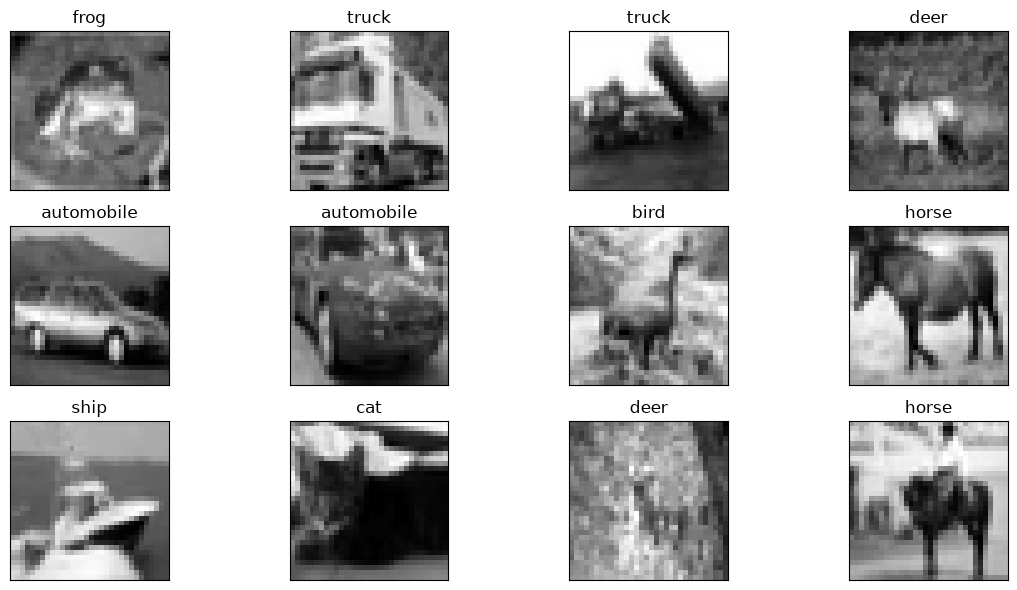

In [6]:
plt.figure(figsize=(12, 6))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()


---
# 2. Construir la red neuronal

Construiremos la misma arquitectura conceptual vista en clase:

```text
Imagen 32×32
   ↓
Flatten
   ↓
1024 valores
   ↓
Dense(128)
   ↓
ReLU
   ↓
Dense(10)
   ↓
Logits
```

> La última capa **no** debe tener Softmax. Trabajaremos con logits.


In [7]:
# TODO 2 — Completa la arquitectura
model = keras.Sequential([
    keras.Input(shape=(32, 32)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10)
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,490 (517.54 KB)

 Trainable params: 132,490 (517.54 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Validación TODO 2
expected_params = (1024 * 128 + 128) + (128 * 10 + 10)
assert model.count_params() == expected_params
print(f"✓ Arquitectura correcta: {model.count_params():,} parámetros")


✓ Arquitectura correcta: 132,490 parámetros


### Preguntas

**2.** ¿Por qué necesitamos `Flatten()` antes de la primera capa `Dense`?

**Respuesta:**

Porque una capa `Dense` recibe un **vector** de features, mientras que cada imagen es una matriz de $32\times32$. `Flatten()` la convierte en un vector de 1024 valores, sin parámetros que aprender, para que cada neurona de `Dense(128)` pueda conectarse con todos los píxeles: cada neurona tiene 1024 pesos y un sesgo.

**3.** ¿Por qué la última capa tiene 10 neuronas?

**Respuesta:**

Porque CIFAR-10 tiene **10 clases**. La red produce un logit por clase, y la predicción es la clase con el logit (o la probabilidad) más alto.

**4.** ¿Qué función cumple `ReLU`?

**Respuesta:**

Introduce **no linealidad**: $g(x)=\max(0,x)$. Sin ella, `Dense(128)` seguida de `Dense(10)` sería equivalente a una sola transformación lineal (una regresión logística). Con ReLU, la capa oculta puede aprender combinaciones no lineales de los píxeles y la red puede representar fronteras de decisión no lineales.

---
# 3. Configurar el entrenamiento

Usaremos:

- `Adam`
- `SparseCategoricalCrossentropy`
- `accuracy`

Como la red produce logits, la pérdida debe configurarse con `from_logits=True`.


In [9]:
lr_rate = 0.001

# TODO 3 — Configura el entrenamiento
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_rate),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)


### Pregunta 5

¿Por qué usamos `from_logits=True`?

**Respuesta:**

Porque la última capa `Dense(10)` **no tiene activación** y produce **logits**, no probabilidades. Con `from_logits=True` la función de pérdida aplica internamente Softmax y la cross-entropy en un solo paso, que es numéricamente más estable (evita calcular $\log$ de números muy cercanos a 0). Si pusiéramos `from_logits=False`, Keras interpretaría los logits como si ya fueran probabilidades y la pérdida sería incorrecta.

---
# 4. Entrenar el modelo

Usaremos 10 épocas y mini-batches de 64 ejemplos. Completa `fit()`.


In [10]:
epochs = 10
batch_size = 64

# TODO 4 — Entrenamiento
history = model.fit(
    X_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_test, y_test),
    shuffle=True
)


Epoch 1/10


  1/782 ━━━━━━━━━━━━━━━━━━━━ 1:01 79ms/step - accuracy: 0.0625 - loss: 2.5700

  6/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.1328 - loss: 2.4805  

 12/782 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.1276 - loss: 2.3828

 17/782 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.1342 - loss: 2.3419

...

765/782 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3972 - loss: 1.7049

771/782 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3969 - loss: 1.7054

777/782 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3970 - loss: 1.7054

782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3973 - loss: 1.7054

782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.3973 - loss: 1.7054 - val_accuracy: 0.3775 - val_loss: 1.7395


### Preguntas

**6.** ¿Qué representa una `epoch`?

**Respuesta:**

Una **epoch** es una pasada completa por las 50 000 imágenes de entrenamiento. En cada epoch el modelo ve cada ejemplo una vez; con `epochs=10` recorre el dataset 10 veces.

**7.** ¿Qué representa `batch_size=64`?

**Respuesta:**

Que los parámetros se actualizan usando **mini-batches de 64 imágenes**: se calcula la pérdida promedio y el gradiente sobre esas 64 imágenes, y Adam actualiza los pesos. Así, cada epoch tiene $\lceil 50000/64 \rceil = 782$ actualizaciones.

## 4.1 Curvas de aprendizaje

Esta parte está resuelta.


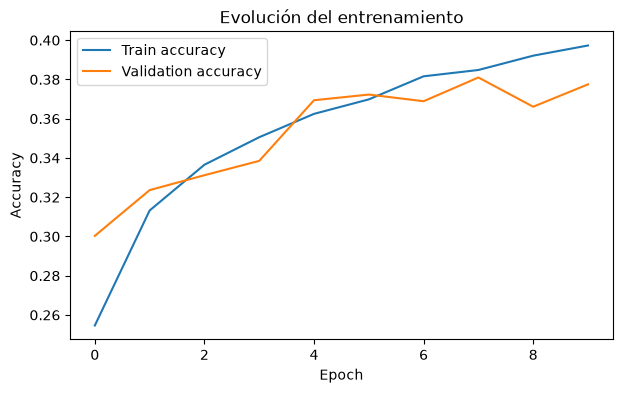

In [11]:
plt.figure(figsize=(7, 4))
plt.plot(history.history["accuracy"], label="Train accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Evolución del entrenamiento")
plt.legend()
plt.show()


### Pregunta 8

Observa las dos curvas. ¿Hay evidencia de overfitting? Justifica brevemente.

**Respuesta:**

**No hay evidencia clara de overfitting.** Las dos curvas suben juntas y terminan muy cerca: train accuracy ≈ 0.397 y validation accuracy ≈ 0.377 en la epoch 10, una brecha de solo ~2 puntos. Además, la val loss sigue bajando (1.97 → 1.74). La validación oscila un poco (0.369 → 0.381 → 0.366 → 0.377), pero no muestra una tendencia descendente mientras train sube. El problema de este modelo es más bien la **falta de capacidad (underfitting)**: incluso en entrenamiento apenas alcanza ~40 %.

---
# 5. Evaluar el modelo

Completa `evaluate()`.


In [12]:
# TODO 5 — Evaluación
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    batch_size=batch_size,
    verbose=0
)

print(f"Test loss     : {test_loss:.4f}")
print(f"Test accuracy : {test_accuracy:.4f}")
print(f"Accuracy (%)  : {test_accuracy * 100:.2f}%")


Test loss     : 1.7395
Test accuracy : 0.3775
Accuracy (%)  : 37.75%


### Pregunta 9

Compara este resultado con Fashion-MNIST, utilizado en clase.

¿CIFAR-10 en escala de grises parece más fácil o más difícil para esta red? Justifica usando el accuracy obtenido.

**Respuesta:**

**CIFAR-10 en escala de grises es mucho más difícil.** Con esta misma receta, la red obtuvo **37.75 %** de accuracy en test, frente a ≈ 88.0 % que obtiene la misma red FC (784 → 128 → 10) en Fashion-MNIST con 10 epochs (`MODEL_TYPE = "fc"` en el notebook de clase), e incluso frente al 84.33 % de la simple regresión logística en Fashion-MNIST. Sigue siendo mejor que el azar (10 %), pero muy lejos de Fashion-MNIST, por estas razones:

- En Fashion-MNIST los objetos están **centrados, alineados y sobre fondo negro uniforme**; en CIFAR-10 son fotos reales, con objetos en distintas posiciones, tamaños y orientaciones, y con fondos variados.
- Al pasar a escala de grises se pierde el **color**, que en CIFAR es una pista importante (cielo azul para aviones, agua para barcos, verde para ranas o ciervos).
- Para una red fully-connected, que cada píxel tenga un peso fijo es muy poco robusto: el mismo gato desplazado unos píxeles activa pesos completamente distintos.

---
# 6. Logits y Softmax

La salida de la red son 10 logits. Para interpretarlos como probabilidades necesitamos Softmax.


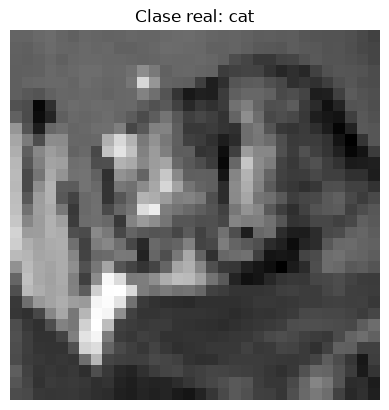

Logits:
[[-0.15990448 -2.1358044   1.153198   -0.3473997   0.63171494 -0.8884189
   0.09338224 -0.27179942 -0.42633945 -2.2666216 ]]


In [13]:
index = 0
image = X_test[index]
true_class = y_test[index]

plt.imshow(image, cmap="gray")
plt.title(f"Clase real: {class_names[true_class]}")
plt.axis("off")
plt.show()

image_batch = np.expand_dims(image, axis=0)
logits = model(image_batch, training=False)

print("Logits:")
print(keras.ops.convert_to_numpy(logits))


In [14]:
# TODO 6 — Logits -> probabilidades
probabilities = keras.ops.softmax(logits)

# TODO 7 — Clase con mayor probabilidad
prediction = keras.ops.argmax(probabilities, axis=1)
prediction = int(keras.ops.convert_to_numpy(prediction)[0])

print("Clase real     :", class_names[true_class])
print("Clase predicha :", class_names[prediction])


Clase real     : cat
Clase predicha : bird


In [15]:
probabilities_np = keras.ops.convert_to_numpy(probabilities)[0]

print("\nProbabilidades:")
for i, p in enumerate(probabilities_np):
    marker = " ← predicción" if i == prediction else ""
    print(f"{class_names[i]:12s}: {p:.4f}{marker}")

print("\nSuma:", probabilities_np.sum())



Probabilidades:
airplane    : 0.0874
automobile  : 0.0121
bird        : 0.3248 ← predicción
cat         : 0.0724
deer        : 0.1928
dog         : 0.0422
frog        : 0.1126
horse       : 0.0781
ship        : 0.0669
truck       : 0.0106

Suma: 1.0


### Pregunta 10

¿Por qué las probabilidades producidas por `Softmax` deben sumar aproximadamente 1?

**Respuesta:**

Porque Softmax normaliza: $P(y_k\mid x) = e^{z_k}/\sum_j e^{z_j}$. Cada término es positivo y todos comparten el mismo denominador, así que la suma es exactamente $\sum_k e^{z_k}/\sum_j e^{z_j}=1$. Así las salidas forman una **distribución de probabilidad** sobre las 10 clases. Se dice "aproximadamente" porque los cálculos en `float32` tienen error de redondeo (en este caso la suma impresa fue 1.0).

---
# 7. Varias predicciones

Esta parte está resuelta. Observa especialmente los errores del modelo.


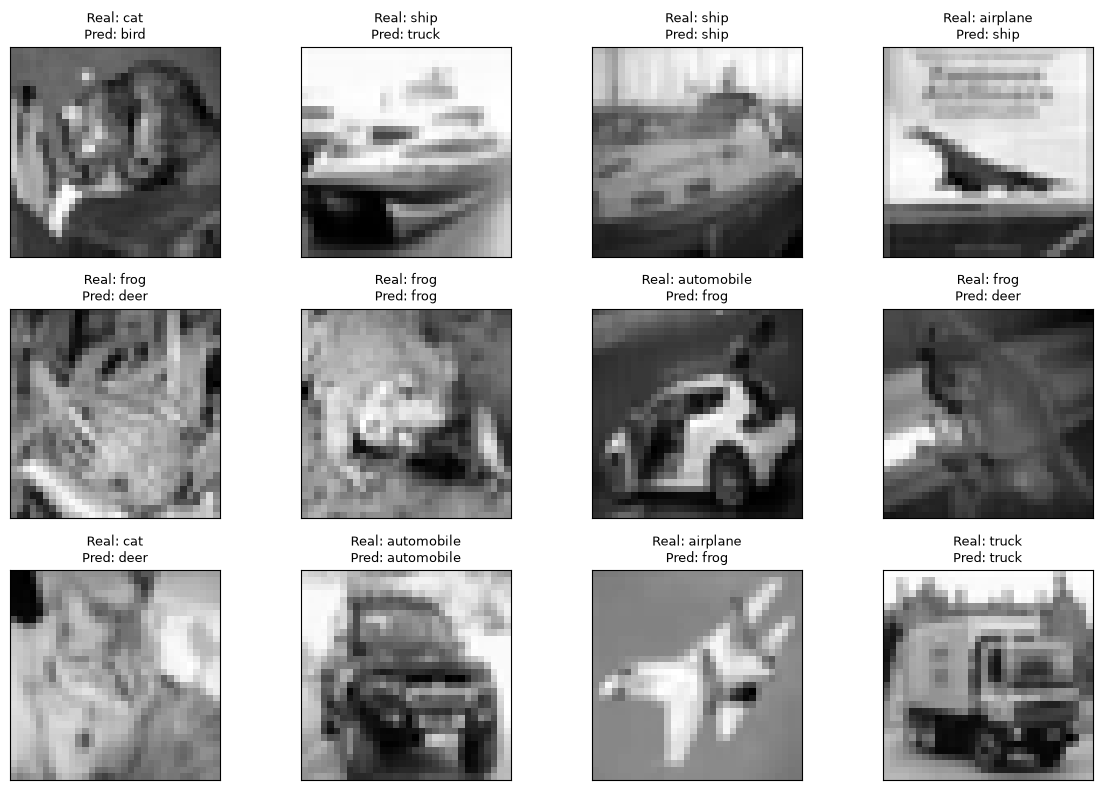

In [16]:
n = 12
logits_batch = model(X_test[:n], training=False)
predictions = keras.ops.argmax(logits_batch, axis=1)
predictions = keras.ops.convert_to_numpy(predictions)

plt.figure(figsize=(12, 8))
for i in range(n):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_test[i], cmap="gray")
    real = class_names[y_test[i]]
    pred = class_names[predictions[i]]
    plt.title(f"Real: {real}\nPred: {pred}", fontsize=9)
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()


---
# 8. Reflexión final

### 1. ¿Cuál fue el accuracy final?

**Respuesta:**

**37.75 %** de accuracy en test (test loss 1.74), y ≈ 39.7 % en entrenamiento.

### 2. ¿Qué clases parecen más difíciles de distinguir?

**Respuesta:**

Según el recall por clase, las más difíciles son **cat (18 %)**, **dog (19 %)**, **airplane (27 %)**, **horse (32 %)** y **deer (32 %)**. Las mejores son frog (59 %), ship (56 %) y automobile (48 %). Las confusiones más frecuentes son cat → frog (254 imágenes), deer → bird (252), airplane → ship (206), airplane → bird (204), dog → frog (199) y truck → automobile (194). Es decir:
- los **animales** se confunden entre sí, porque tienen formas, texturas y fondos naturales parecidos;
- **airplane / ship / bird** se confunden porque comparten fondos uniformes (cielo o mar), que en gris son casi idénticos;
- **truck / automobile** son vehículos con siluetas parecidas.

En la visualización de las 12 primeras imágenes se ven justamente errores de este tipo: cat → bird, airplane → ship, frog → deer.

### 3. Después de `Flatten()`, la imagen se convierte en un vector de 1024 valores. ¿Qué información importante sobre la imagen podría perderse al tratarla únicamente como un vector?

**Respuesta:**

Se pierde la **estructura espacial explícita**: qué píxeles son vecinos, la forma 2D del objeto y los patrones locales (bordes, esquinas, texturas). Para la red, el píxel (5,5) y el (5,6) son dos entradas independientes, igual que dos píxeles en extremos opuestos. Además, el modelo **no es invariante a traslaciones**: si el objeto se desplaza, aunque sea un poco, los mismos patrones caen sobre pesos distintos y la red tiene que volver a aprenderlos en cada posición.

### 4. ¿Qué tipo de arquitectura podría aprovechar mejor la estructura espacial de las imágenes?

**Respuesta:**

Las **redes neuronales convolucionales (CNNs)**. Sus filtros recorren la imagen y detectan patrones locales con los **mismos pesos en todas las posiciones** (*weight sharing*), lo que reduce mucho los parámetros y da cierta invariancia a traslaciones. El *pooling* y la composición de capas construyen jerarquías: bordes → texturas → partes → objetos.

---

## Para pensar

Nuestro modelo hace:

```text
32×32 → Flatten → 1024 valores → Dense → ReLU → Dense(10)
```

Sin embargo, una imagen tiene **estructura espacial**: existen bordes, formas y patrones locales.

Este resultado nos deja preparada la siguiente pregunta del curso:

> **¿Cómo puede una red aprovechar directamente la estructura espacial de una imagen?**

La respuesta será: **Convolutional Neural Networks (CNNs)**.